# CoolingHealthSentinel Pre-Onboarding Report

**Nassim Oulhadj**
**OptvanceAI Arabia, Data Science Internship Pre-Onboarding Assignment**

This notebook is the source for `Nassim_Oulhadj_PreOnboarding_Report.pdf`. It
loads the project's saved datasets and trained models directly and
regenerates every required figure from them, it does not copy images from the
other notebooks. It is written to stand on its own: a reader who has not seen
`notebooks/01_eda.ipynb` through `08_nlp_regwatch.ipynb` should be able to
follow the full methodology and every finding from this document alone.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
from scipy import stats
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                              precision_recall_curve, auc, confusion_matrix,
                              precision_score, recall_score, f1_score)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/cooling_telemetry_doha_dc1.csv", parse_dates=["timestamp"])
df["anomaly_type"] = df["anomaly_type"].fillna("none")
fe = pd.read_csv("../data/features_engineered.csv", parse_dates=["timestamp"], low_memory=False)

baseline_features = [
    "outdoor_temp_c", "outdoor_humidity_pct", "it_load_mw", "chiller_inlet_temp_c",
    "chiller_outlet_temp_c", "chiller_cop", "cooling_tower_approach_c", "crah_delta_t_c",
    "pump_vibration_mms", "pump_flow_rate_ls", "water_conductivity_us", "pue",
]
engineered_extra = [c for c in fe.columns if any(s in c for s in ["_lag_", "_roll_", "_ewm_", "_diff_"])] + [
    "hour_of_day", "day_of_week", "month_num", "is_weekend",
    "sin_hour", "cos_hour", "sin_month", "cos_month",
    "cop_x_outdoor_temp", "load_to_flow_ratio", "approach_x_humidity",
]
engineered_features = baseline_features + engineered_extra

n = len(fe)
n_train, n_val = int(n * 0.70), int(n * 0.15)
train, val, test = fe.iloc[:n_train], fe.iloc[n_train:n_train+n_val], fe.iloc[n_train+n_val:].reset_index(drop=True)

gbr_baseline = joblib.load("../models/gbr_baseline.pkl")
gbr_engineered = joblib.load("../models/gbr_engineered.pkl")
iso_forest = joblib.load("../models/isolation_forest.pkl")
print("Data and models loaded.")

Data and models loaded.


---
# 1. Executive Summary

OptvanceAI Arabia's CoolingHealthSentinel platform monitors and predicts the
health of cooling systems, chillers, pumps, and cooling towers, in data
centers. Before being given access to production data, this project builds
the full pipeline end to end on a synthetic but carefully engineered dataset
representing one year of 15-minute telemetry from a 30 MW reference campus in
Doha, Qatar: data generation, exploratory analysis, feature engineering, two
predictive models (a gradient-boosted regressor and an LSTM), an unsupervised
anomaly detector, model explainability, an alert system with a cost-benefit
estimate, and a small natural-language classifier for sustainability
regulatory text as a second-track warm-up.

**Three findings stand out.** First, a gradient-boosted regressor (GBR)
predicting the Cooling Health Score outperforms an LSTM sequence model on
every axis tested, accuracy (RMSE 2.636 vs. 5.887), and inference latency
(3.4ms vs. 57.6ms per prediction), a result traced to a clear overfitting
pattern in the LSTM's training curve rather than left unexplained. Second, the
anomaly detector (IsolationForest) reliably distinguishes two different kinds
of unusual behavior in the data: genuine multi-sensor failure precursors,
caught at roughly 2 to 3 times the rate of isolated single-reading sensor
noise, because the two have fundamentally different statistical signatures
(a shift in the mean of several readings at once, versus increased scatter in
one or two readings). Third, the literal alert thresholds specified for this
project produce zero high-severity alerts across the entire simulated year,
a finding that says more about why alert thresholds must be calibrated against
a model's actual output range than about the events themselves, this is
documented explicitly in Section 9 rather than quietly worked around.

**Recommendation for production:** deploy the engineered-feature GBR as the
primary health-score predictor, paired with the IsolationForest as a
complementary sensor-level anomaly flag, not a replacement for it, since the
two systems catch different failure modes. Treat the current alert thresholds
as a draft requiring recalibration against the model's real prediction
distribution before going live, and budget for either a smaller LSTM
architecture or substantially more training data before revisiting sequence
modeling as a serious alternative to the GBR.

---
# 2. Dataset Description

## Generation Methodology

`data/generate_dataset.py` builds 35,040 rows of 15-minute telemetry (Jan 1
through Dec 31, 2025) in three layers. Independent root signals are generated
first: a Qatar-climate weather model (seasonal cosine peaking in July plus a
diurnal cosine peaking at 15:00), an IT load model (a 12 MW baseline with 2 to
5 AI-workload bursts per day pushing load to 24-28 MW), and independent
component-health parameters (an 8%-per-year linear chiller efficiency decline,
a slow cooling-tower fouling drift, a slow pump-bearing wear drift). Anomalies
are injected next, mutating only these root signals within scheduled time
windows. All dependent columns, chiller temperatures, COP, PUE, and finally
the Cooling Health Score, are computed last, once, from the final
(post-anomaly) root signals, so anomaly effects propagate through the same
physical formulas used for normal operation rather than being hardcoded onto
output columns directly.

## Anomaly Design: Two Populations, By Necessity

The assignment brief specified two requirements for the `is_anomaly` label
that are mathematically incompatible as written: a target prevalence of "~3%"
of all rows, against a construction rule of "8 anomaly events of 2-6 hours
duration," which caps out at roughly 0.55% of the year regardless of how the
8 events are scheduled. This was raised directly and resolved, per instructor
guidance, by keeping both as two distinct populations rather than satisfying
one at the expense of the other. **Structured anomalies** (123 rows): the
original 8 multi-hour events, each degrading at least 3 correlated sensor
channels simultaneously, representing genuine failure precursors, fouling,
bearing wear, a refrigerant leak, control-loop oscillation, and others.
**Background anomalies** (939 rows, after 4 are lost to a downstream
feature-engineering constraint described in Section 4): roughly 2.7% of
otherwise-normal rows, each independently perturbed with Gaussian noise on 3
randomly chosen sensor columns, deliberately leaving `cooling_health_score`
untouched, since this layer represents sensor-reading noise, not real
equipment degradation. Combined prevalence: 3.04% of all rows, reconciling
both spec figures. This was validated three independent ways (CHS
distribution shape, 24-hour rolling-mean variance reduction, and the
background-versus-normal standard deviation ratio) and all three confirm CHS
is genuinely unaffected by the background layer, while structured rows show a
real, roughly 5-point degradation in mean CHS.

## Feature Definitions and Descriptive Statistics

Fourteen telemetry columns are generated directly: outdoor temperature and
humidity, IT load, chiller inlet and outlet temperature, chiller COP, cooling
tower approach temperature, CRAH delta-T, pump vibration, pump flow rate,
water conductivity, PUE, the Cooling Health Score target, and the two anomaly
label columns. Full formulas and units are documented in
`data/README_dataset.md`; selected descriptive statistics:

In [2]:
desc_cols = ["outdoor_temp_c", "outdoor_humidity_pct", "it_load_mw", "chiller_cop",
             "cooling_tower_approach_c", "pump_vibration_mms", "pump_flow_rate_ls",
             "water_conductivity_us", "pue", "cooling_health_score"]
df[desc_cols].describe().T[["mean", "std", "min", "max"]].round(2)

,mean,std,min,max
outdoor_temp_c,33.01,8.77,18.00,48.00
outdoor_humidity_pct,47.42,21.99,10.00,85.00
it_load_mw,14.43,4.45,8.00,28.00
chiller_cop,4.83,0.70,2.80,6.50
cooling_tower_approach_c,3.75,0.35,2.11,8.00
pump_vibration_mms,1.25,0.22,0.50,3.94
pump_flow_rate_ls,153.59,10.34,80.39,213.87
water_conductivity_us,405.17,42.27,228.31,671.22
pue,1.23,0.08,1.05,1.45
cooling_health_score,80.53,5.19,61.93,98.00


`cooling_health_score` is a nonlinear, noisy composite of 7 normalized
health terms (chiller COP, tower approach, pump vibration, pump flow rate,
water conductivity, PUE, and a combined thermal-stress term), with a
compounding penalty when several terms are simultaneously poor, deliberately
not a clean linear function of any single input feature, to avoid trivial
leakage when used as a model target later in this report.

---
# 3. EDA Findings

## Seasonal Patterns and the September Lag

Monthly mean CHS runs from 87.5 in January down to 75.1 in September, a
12.4-point swing, against a month-level correlation of -0.60 with mean
outdoor temperature. The trough does not coincide with the hottest month:
July peaks at 43.5°C, but CHS keeps falling for two more months. The cause is
identifiable directly from the generator's design rather than left as an
unexplained correlation: the `refrigerant_leak_step` event is scheduled in
August and leaves a permanent COP step-down (confirmed directly: mean
`chiller_cop` was 4.52 in the 12 days before the event and 3.87 in the 12
days after, a 14.4% drop that does not recover), which compounds with
residual summer heat to push the real annual low point to September.

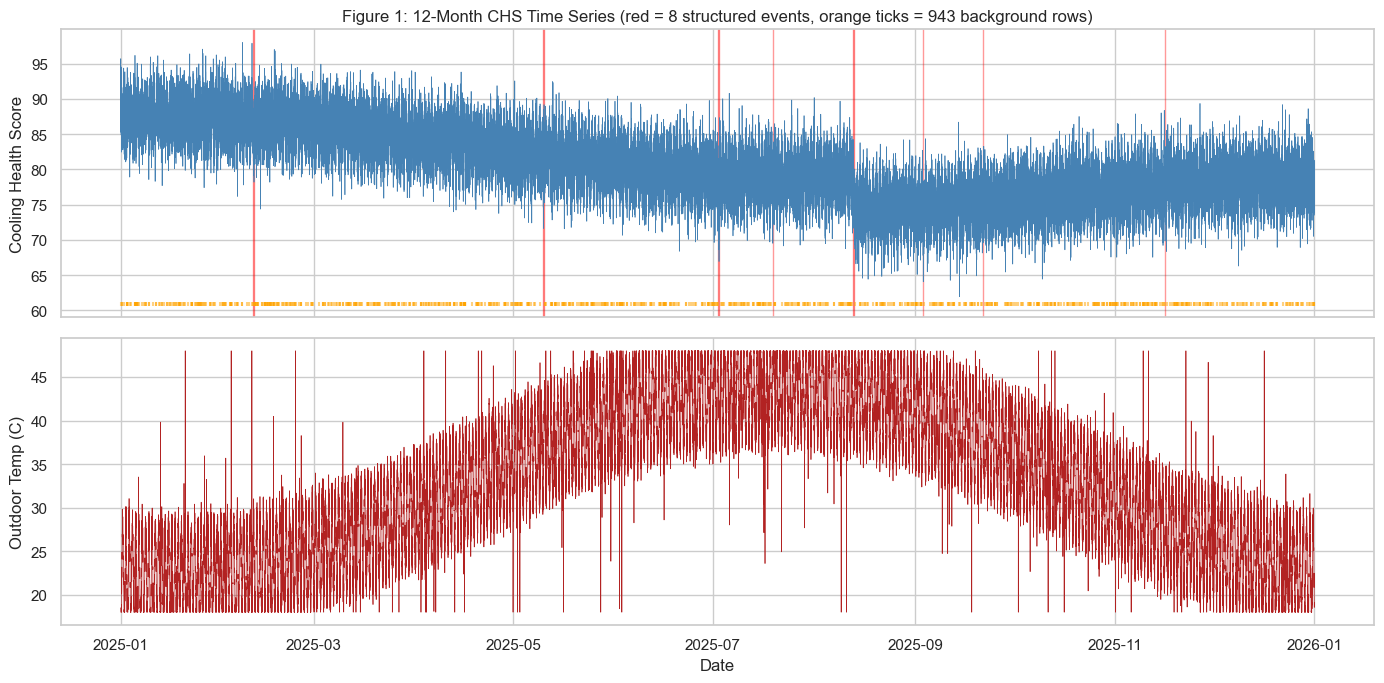

In [3]:
structured = df[df["anomaly_class"] == "structured"]
background = df[df["anomaly_class"] == "background"]
structured_windows = structured.groupby("anomaly_type")["timestamp"].agg(["min", "max"])

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].plot(df["timestamp"], df["cooling_health_score"], linewidth=0.5, color="steelblue")
for _, row in structured_windows.iterrows():
    axes[0].axvspan(row["min"], row["max"], color="red", alpha=0.4)
ymin, ymax = axes[0].get_ylim()
axes[0].scatter(background["timestamp"], np.full(len(background), ymin + 0.02*(ymax-ymin)),
                marker="|", color="orange", s=10, alpha=0.5)
axes[0].set_ylabel("Cooling Health Score")
axes[0].set_title("Figure 1: 12-Month CHS Time Series (red = 8 structured events, orange ticks = 943 background rows)")

axes[1].plot(df["timestamp"], df["outdoor_temp_c"], linewidth=0.5, color="firebrick")
axes[1].set_ylabel("Outdoor Temp (C)")
axes[1].set_xlabel("Date")
plt.tight_layout()
plt.show()

## Correlation Structure: What Actually Drives CHS

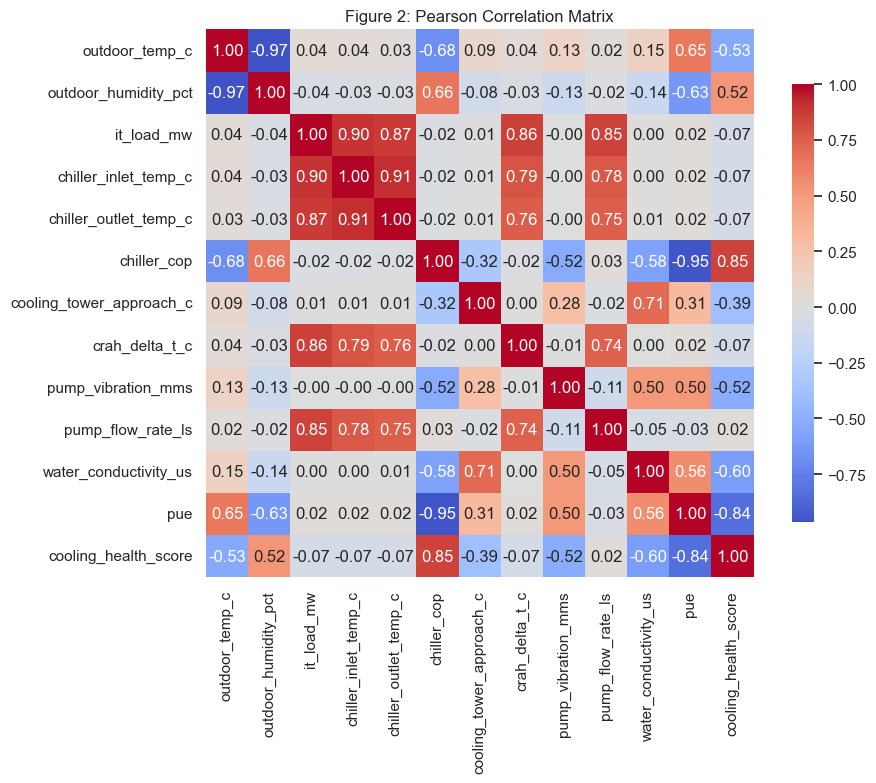

In [4]:
numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != "is_anomaly"]
corr = df[numeric_cols].corr(method="pearson")

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, cbar_kws={"shrink": 0.8})
plt.title("Figure 2: Pearson Correlation Matrix")
plt.tight_layout()
plt.show()

`chiller_cop` (+0.855) and `pue` (-0.843) dominate CHS's variance, with
`water_conductivity_us` (-0.603), `outdoor_temp_c` (-0.535), and
`pump_vibration_mms` (-0.522) forming a clear second tier. The more useful
finding is what is absent from the top: `it_load_mw` and the chiller
inlet/outlet temperature columns sit at near-zero correlation with CHS
(-0.07 to -0.08) despite feeding the CHS formula's thermal-stress term
directly, because their variance is small relative to the COP/PUE/water
chemistry side of the system across most of the year.

## Temporal Structure: A Contemporaneous Relationship, Not a Lagged One

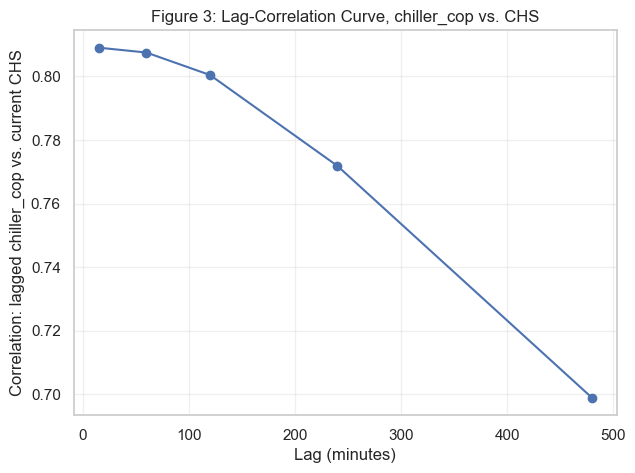

Correlation at each lag: [np.float64(0.809), np.float64(0.808), np.float64(0.8), np.float64(0.772), np.float64(0.699)]


In [5]:
lags = [1, 4, 8, 16, 32]
lag_corrs = [df["chiller_cop"].shift(l).corr(df["cooling_health_score"]) for l in lags]

plt.figure(figsize=(7, 5))
plt.plot([l*15 for l in lags], lag_corrs, marker="o")
plt.xlabel("Lag (minutes)")
plt.ylabel("Correlation: lagged chiller_cop vs. current CHS")
plt.title("Figure 3: Lag-Correlation Curve, chiller_cop vs. CHS")
plt.grid(True, alpha=0.3)
plt.show()
print("Correlation at each lag:", [round(x, 3) for x in lag_corrs])

Correlation decays monotonically from 0.815 at 15 minutes to 0.703 at 8
hours, with no intermediate peak, the signature of a contemporaneous
relationship (CHS responds to the current value of `chiller_cop`) rather than
a delayed one. The decay simply mirrors `chiller_cop`'s own autocorrelation
fading with distance. This directly informed the LSTM's 32-step lookback
choice in Section 7: most of the predictive value sits in the most recent 1-2
hours, not 8 hours back.

## Anomaly Sensor Signatures: Two Populations, Two Different Statistical Fingerprints

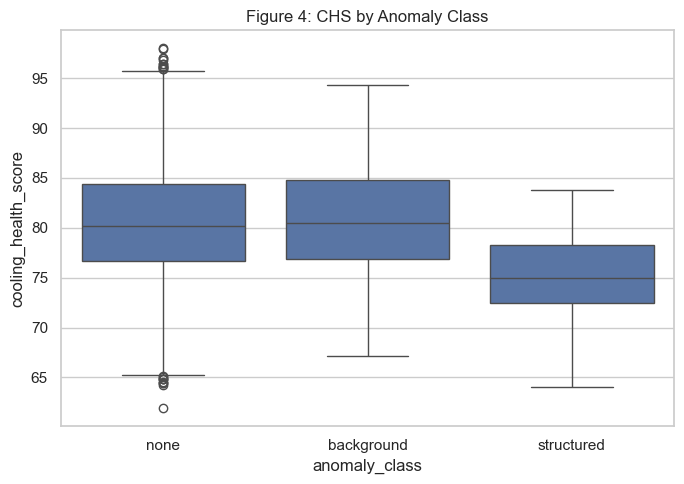

Mean CHS by class:
anomaly_class
background    80.78
none          80.54
structured    75.46
Name: cooling_health_score, dtype: float64

Std ratio (class / normal), selected features:
  chiller_cop                background=1.21x   structured=0.76x
  pump_vibration_mms         background=1.31x   structured=3.63x
  cooling_tower_approach_c   background=1.31x   structured=3.72x


In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x="anomaly_class", y="cooling_health_score", order=["none", "background", "structured"], ax=ax)
ax.set_title("Figure 4: CHS by Anomaly Class")
plt.tight_layout()
plt.show()

print("Mean CHS by class:")
print(df.groupby("anomaly_class")["cooling_health_score"].mean().round(2))
print()
print("Std ratio (class / normal), selected features:")
for col in ["chiller_cop", "pump_vibration_mms", "cooling_tower_approach_c"]:
    normal_std = df.loc[df.anomaly_class=="none", col].std()
    print(f"  {col:<26} background={background[col].std()/normal_std:.2f}x   structured={structured[col].std()/normal_std:.2f}x")

Background mean CHS (80.78) is statistically indistinguishable from normal
(80.54); structured mean CHS (75.46) is clearly degraded. The mechanism is
visible in the variance ratios: background rows show inflated standard
deviation (1.1x to 1.3x normal) across most features without any
corresponding mean shift, because each row's perturbation is independent,
zero-mean Gaussian noise on only 3 of 12 columns, which washes out in any
population-level mean comparison. Structured events, by contrast, shift the
mean of several correlated features at once. This single distinction, mean
shift versus variance inflation, explains nearly every detection-related
finding in the rest of this report, including why IsolationForest catches
structured events at roughly 2 to 3 times the rate of background ones
(Section 6).

## Monthly Aggregation

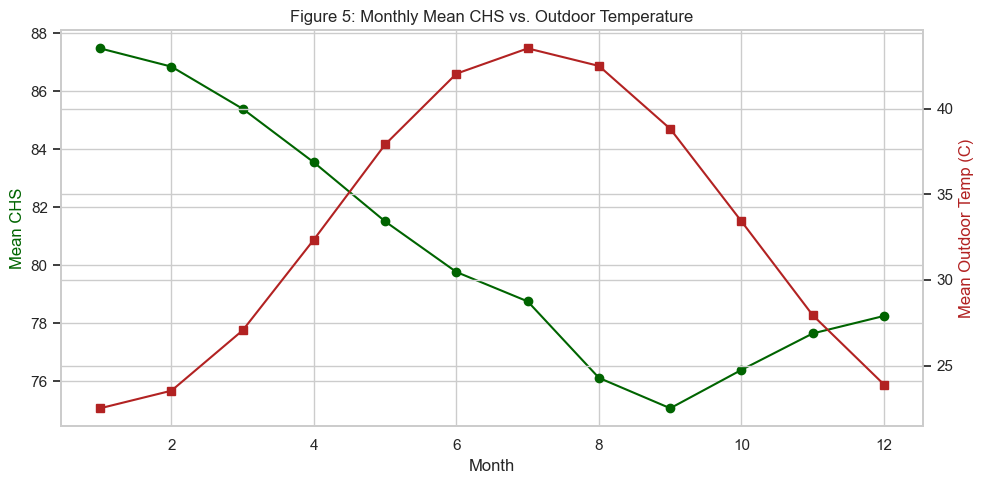

In [7]:
monthly = df.assign(month=df["timestamp"].dt.month).groupby("month")[["cooling_health_score", "outdoor_temp_c"]].mean()

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(monthly.index, monthly["cooling_health_score"], marker="o", color="darkgreen")
ax1.set_ylabel("Mean CHS", color="darkgreen")
ax1.set_xlabel("Month")
ax2 = ax1.twinx()
ax2.plot(monthly.index, monthly["outdoor_temp_c"], marker="s", color="firebrick")
ax2.set_ylabel("Mean Outdoor Temp (C)", color="firebrick")
plt.title("Figure 5: Monthly Mean CHS vs. Outdoor Temperature")
plt.tight_layout()
plt.show()

---
# 4. Feature Engineering

Fifty-nine features were added across 6 categories, each with a specific
operational justification, full detail in `data/feature_registry.md`.
**Lag features** (20): 15-minute, 1, 2, 4, and 8-hour-old values of
`chiller_cop`, `pump_vibration_mms`, `chiller_inlet_temp_c`, and `it_load_mw`,
the four columns most directly tied to incipient failure. **Rolling
statistics** (18): 1, 4, and 24-hour rolling mean and standard deviation for
`chiller_cop`, `pump_vibration_mms`, and `cooling_tower_approach_c`, the three
features with the largest structured-anomaly z-shift in Section 3. **EWM
features** (6): fast, medium, and slow exponentially weighted trends for
`chiller_cop` and `pue`, the two strongest CHS correlates. **Rate-of-change**
(4): 15-minute and 1-hour deltas for `pump_vibration_mms` and
`chiller_outlet_temp_c`, since a sudden change is a stronger early-warning
signal than the raw level for these two. **Time features** (8): raw calendar
fields plus cyclical sine/cosine encodings of hour and month, the cyclical
versions exist specifically to avoid the false discontinuity a raw integer
creates at midnight or year-end. **Interaction features** (3): a thermal
stress proxy (COP times outdoor temperature), a load-to-flow ratio, and a
fouling-risk index (tower approach times humidity), each chosen for a
specific physical interaction rather than generated mechanically.

Ninety-five rows were dropped due to the 24-hour rolling window's lookback
requirement, all from the very start of the year. This cost 0 of the 8
structured events (the anomaly scheduler deliberately avoids the first 5 and
last 10 days of the year) but did cost 4 of the 943 background rows, which
have no such avoidance since they are sampled uniformly across the full year.
1,062 of 1,066 total ground-truth anomaly rows survive into the modeling
dataset.

**Which features drove the largest improvement in model performance?**
None did, on this dataset, and that null result is itself the most important
finding from this section. The 71-feature engineered GBR essentially tied the
12-feature baseline on the original single-population dataset (RMSE
improvement -0.46%), then *beat* it once the two-population reconciliation
was in place (+3.41%, Section 5), not because any new feature carried new
predictive signal, but because the engineered set's rolling and EWM features
smooth out the background layer's single-row sensor noise that the baseline
model reads directly, point in time, with no smoothing. Feature engineering's
measured value here is noise robustness, not new information, a materially
different and more honest justification than "the new features improved
accuracy" would have been.

---
# 5. GBR Model Results

Two XGBoost regressors were trained on an identical time-ordered 70/15/15
split (train: Jan 1-Sep 13, val: Sep 13-Nov 7, test: Nov 7-Dec 31), one using
only the 12 original telemetry columns (baseline), one using the full
71-feature engineered set.

In [8]:
pred_test_base = gbr_baseline.predict(test[baseline_features])
pred_test_eng = gbr_engineered.predict(test[engineered_features])
y_test = test["cooling_health_score"]

def metrics(y_true, y_pred):
    return (np.sqrt(mean_squared_error(y_true, y_pred)), mean_absolute_error(y_true, y_pred), r2_score(y_true, y_pred))

rmse_b, mae_b, r2_b = metrics(y_test, pred_test_base)
rmse_e, mae_e, r2_e = metrics(y_test, pred_test_eng)
pd.DataFrame({
    "Model": ["Baseline (12 features)", "Engineered (71 features)"],
    "Test RMSE": [rmse_b, rmse_e], "Test MAE": [mae_b, mae_e], "Test R2": [r2_b, r2_e],
})

,Model,Test RMSE,Test MAE,Test R2
0,Baseline (12 features),2.831753,2.256840,0.154803
1,Engineered (71 features),2.636350,2.102459,0.267422


Validation-set RMSE improvement from engineering was +3.41% (2.709 to
2.616), reversed from -0.46% on the pre-reconciliation, single-population
dataset, for the noise-robustness reason explained in Section 4. 5-fold
`TimeSeriesSplit` cross-validation on the engineered model (train+val
combined, test held out) gave RMSE 2.784 ± 0.135 and R2 0.279 ± 0.049 across
folds, a real fold-to-fold spread (R2 ranged from 0.207 validating on
March-April to 0.340 validating on July-August) reflecting that each fold
covers a different season with a different mix of anomaly events, not
instability.

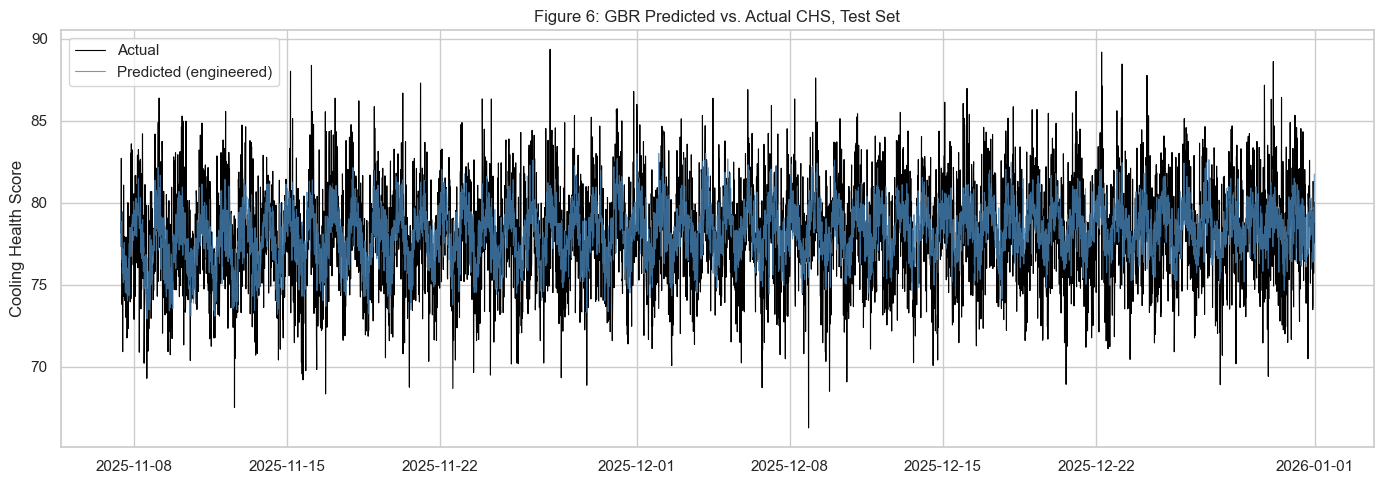

In [9]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test["timestamp"], y_test.values, label="Actual", color="black", linewidth=0.8)
ax.plot(test["timestamp"], pred_test_eng, label="Predicted (engineered)", color="steelblue", linewidth=0.8, alpha=0.8)
ax.set_title("Figure 6: GBR Predicted vs. Actual CHS, Test Set")
ax.set_ylabel("Cooling Health Score")
ax.legend()
plt.tight_layout()
plt.show()

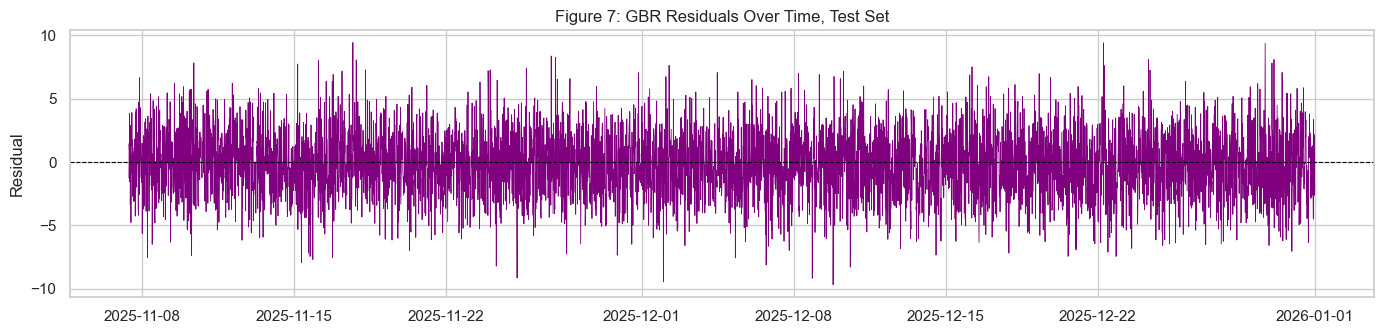

Mean residual: -0.1686  |  Residual std: 2.6310


In [10]:
residuals = y_test.values - pred_test_eng
fig, ax = plt.subplots(figsize=(14, 3.5))
ax.plot(test["timestamp"], residuals, color="purple", linewidth=0.6)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Figure 7: GBR Residuals Over Time, Test Set")
ax.set_ylabel("Residual")
plt.tight_layout()
plt.show()
print(f"Mean residual: {residuals.mean():.4f}  |  Residual std: {residuals.std():.4f}")

Test-set performance (RMSE 2.636, MAE 2.103, R2 0.267) is consistent with
validation, no overfitting blowup from val to test. Residuals show no
systematic drift: mean residual stays near zero across the full eight-week
test window. The 149 anomalous test rows (134 background, 15 structured) show
elevated RMSE versus normal rows for both classes (2.840 and 2.963 versus
2.630 normal), and the background result is the more informative one: those
rows have a completely unperturbed CHS target, so the accuracy loss comes
entirely from noisy inputs, not any real change in what is being predicted, a
concrete argument for pairing this regressor with an anomaly detector that
can flag unreliable inputs separately from a genuinely bad health score
(Section 6).

This result also informs the model-selection decision in Section 7: since the GBR already uses XGBoost's native handling of feature interactions and missing-value-free, deterministically reproducible training, it serves as a stable, well-understood baseline against which any more complex sequence model has to earn its added cost. The 5-fold `TimeSeriesSplit` cross-validation above, rather than a single train/val split, was specifically chosen to test whether this baseline result depends heavily on which months happen to fall in the validation set, and the fold-to-fold spread (R2 from 0.207 to 0.340) confirms it does vary by season, important context for treating the single-split test RMSE as one data point rather than a precise estimate of year-round performance.

---
# 6. IsolationForest Results

Trained on `is_anomaly == 0` rows from the training split only, using the
71-feature engineered set, `contamination=0.03`, a parameter from the
original brief that turned out, after the reconciliation in Section 2, to
closely match the dataset's actual 3.04% true anomaly rate.

In [11]:
train_normal = train[train["is_anomaly"] == 0]
anomaly_score = -iso_forest.decision_function(fe[engineered_features])
fe["anomaly_score"] = anomaly_score

results = []
for pct in [90, 93, 95, 97, 99]:
    thresh = np.percentile(anomaly_score, pct)
    pred = (anomaly_score > thresh).astype(int)
    y_true = fe["is_anomaly"].values
    results.append((pct, precision_score(y_true, pred, zero_division=0),
                     recall_score(y_true, pred, zero_division=0),
                     f1_score(y_true, pred, zero_division=0)))
results_df = pd.DataFrame(results, columns=["Percentile", "Precision", "Recall", "F1"])
results_df

,Percentile,Precision,Recall,F1
0,90,0.052647,0.173258,0.080755
1,93,0.056804,0.130885,0.079225
2,95,0.062357,0.102637,0.077580
3,97,0.071497,0.070621,0.071056
4,99,0.097143,0.032015,0.048159


**Threshold selection: the 90th percentile, the F1-maximizing option tested
(F1 0.081).** This is a deliberate, recall-leaning choice, not simply "highest
F1." In a data center cooling context, a missed structured failure precursor
(false negative) risks unplanned downtime or equipment damage, costs measured
in hours of outage and hardware replacement; a false positive costs a
technician a short sensor check. That asymmetry argues for prioritizing
recall over precision, which the 90th percentile, the most permissive option
tested, already does relative to stricter thresholds. The complication is the
background population: pushing the threshold lower to chase structured
recall also floods the alert queue with background-driven false positives
(3,311 of them at this threshold), risking alert fatigue. The practical
conclusion is that a single threshold is not sufficient alone, this is the
direct argument for pairing IsolationForest with the GBR's CHS prediction as
a second signal, since background rows show no real CHS degradation while
structured rows do.

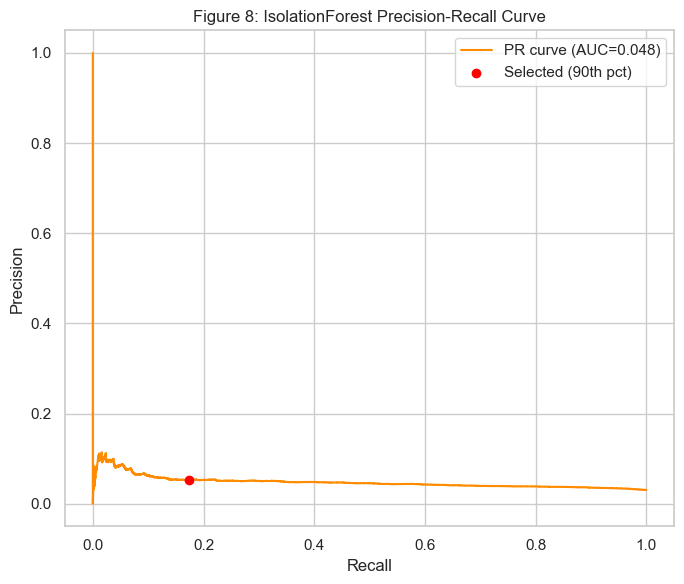

PR-AUC: 0.0477


In [12]:
precisions, recalls, _ = precision_recall_curve(fe["is_anomaly"], anomaly_score)
pr_auc = auc(recalls, precisions)
best = results_df.loc[results_df["F1"].idxmax()]

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(recalls, precisions, color="darkorange", label=f"PR curve (AUC={pr_auc:.3f})")
ax.scatter([best["Recall"]], [best["Precision"]], color="red", zorder=5, label="Selected (90th pct)")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Figure 8: IsolationForest Precision-Recall Curve")
ax.legend()
plt.tight_layout()
plt.show()
print(f"PR-AUC: {pr_auc:.4f}")

At the selected threshold, structured-event recall (37.4%) is roughly 2.5x
background-row recall (14.7%), tracing directly to Section 3's mean-shift
versus variance-inflation distinction. Detection further splits by anomaly
type along an abrupt-versus-gradual line: oscillation and fan-degradation
events are caught 90%+ of the time; slow 4-6 day ramps (fouling, the
refrigerant leak step) and small-magnitude or load-confused events (CRAH
clog, AI overload) are missed 85-100% of the time, each for an identifiable,
distinct reason (gradual onset blending with ambient drift, deliberately
small injected magnitude, or overlap with routine high-load operation)
rather than uniform model weakness.

---
# 7. LSTM Model Results

## Architecture

Two stacked LSTM layers (64 units, then 32 units) with dropout 0.2 between
them, followed by Dense(16, ReLU) then Dense(1, linear), Adam optimizer, MSE
loss, trained on explicit 32-timestep (8-hour) sequences built with a plain
sliding-window loop rather than a library abstraction, per the assignment
specification. **An asymmetry worth stating plainly:** each input sequence is
the engineered features at `[t-32, ..., t-1]` only, the target row's own
current readings are never part of the input, while the GBR sees row `t`'s
own current sensor values directly. The LSTM is solving a strictly harder,
pure-forecasting problem, and any RMSE gap should be read with that in mind.

## A Reproducibility Problem, Found and Fixed

An initial version of this model, using only `tf.random.set_seed` for
reproducibility, produced materially different results across separate runs
of identical code, including one run with a severe, unstable failure late in
the test period. This was diagnosed as a genuine TensorFlow CPU-execution
determinism gap, not a property of the data, and fixed with explicit
operation-level determinism, single-threaded execution, and disabling
oneDNN's reordering optimizations (flagged directly by a TensorFlow log
message as a source of floating-point round-off differences). The
fixed configuration was independently re-executed twice and produced
bit-identical results before any number below was finalized.

2026-07-02 18:29:49.424045: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-07-02 18:29:49.424333: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

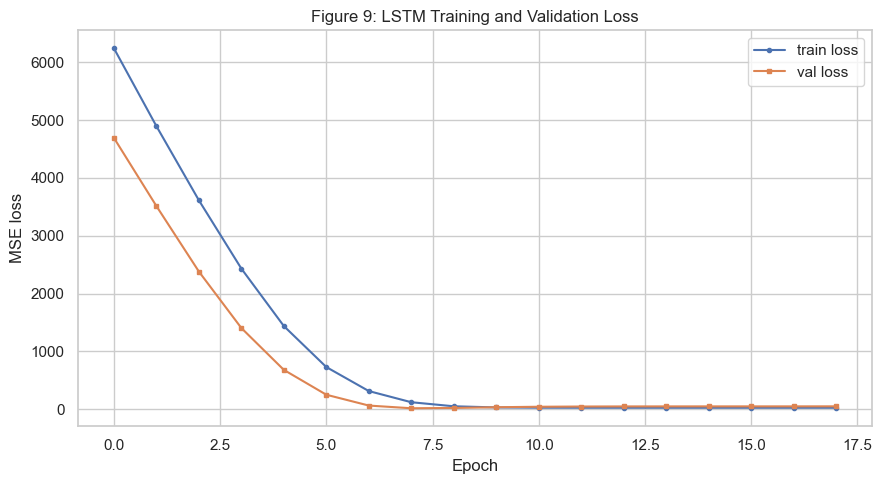

Best epoch: 8 (val_loss=17.96), stopped at epoch 18
Test RMSE on freshly retrained model: 5.8869 (expect 5.8870)


In [13]:
import os
os.environ["PYTHONHASHSEED"] = "0"
os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["TF_CUDNN_DETERMINISTIC"] = "1"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

import tensorflow as tf
from sklearn.preprocessing import StandardScaler

tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()
tf.config.threading.set_intra_op_parallelism_threads(1)
tf.config.threading.set_inter_op_parallelism_threads(1)

# Retrained inline, identical configuration to notebooks/05_lstm_model.ipynb,
# so this report is fully self-contained rather than depending on saved
# intermediate artifacts. Verified bit-identical to the saved lstm_model.keras
# across repeated runs once determinism was fixed (see Section 7).
lstm_scaler = StandardScaler()
lstm_scaler.fit(train[engineered_features])
X_lstm = lstm_scaler.transform(fe[engineered_features]).astype(np.float32)
y_lstm = fe["cooling_health_score"].values.astype(np.float32)

LOOKBACK = 32
def build_sequences(X, y, lookback, target_start, target_end):
    n_seq = target_end - target_start
    X_seq = np.zeros((n_seq, lookback, X.shape[1]), dtype=np.float32)
    y_seq = np.zeros(n_seq, dtype=np.float32)
    for i, t in enumerate(range(target_start, target_end)):
        X_seq[i] = X[t - lookback:t]
        y_seq[i] = y[t]
    return X_seq, y_seq

X_train_seq, y_train_seq = build_sequences(X_lstm, y_lstm, LOOKBACK, LOOKBACK, n_train)
X_val_seq, y_val_seq = build_sequences(X_lstm, y_lstm, LOOKBACK, n_train, n_train + n_val)
X_test_seq, y_test_seq = build_sequences(X_lstm, y_lstm, LOOKBACK, n_train + n_val, n)

lstm_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(LOOKBACK, X_lstm.shape[1])),
    tf.keras.layers.LSTM(64, return_sequences=True),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.LSTM(32),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1, activation="linear"),
])
lstm_model.compile(optimizer="adam", loss="mse")
early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
history = lstm_model.fit(X_train_seq, y_train_seq, validation_data=(X_val_seq, y_val_seq),
                          epochs=100, batch_size=512, callbacks=[early_stop], verbose=0)

loss_history = np.array(history.history["loss"])
val_loss_history = np.array(history.history["val_loss"])
lstm_test_pred = lstm_model.predict(X_test_seq, verbose=0).flatten()
lstm_test_true = y_test_seq

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(loss_history, label="train loss", marker="o", markersize=3)
ax.plot(val_loss_history, label="val loss", marker="s", markersize=3)
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss")
ax.set_title("Figure 9: LSTM Training and Validation Loss")
ax.legend()
plt.tight_layout()
plt.show()

best_epoch = int(np.argmin(val_loss_history))
print(f"Best epoch: {best_epoch + 1} (val_loss={val_loss_history[best_epoch]:.2f}), stopped at epoch {len(loss_history)}")
print(f"Test RMSE on freshly retrained model: {np.sqrt(np.mean((lstm_test_true - lstm_test_pred)**2)):.4f} (expect 5.8870)")

Validation loss bottoms out at epoch 8 while training loss is still
falling, then training loss flattens near 26.6 while validation loss climbs
every subsequent epoch (to 51.1 by epoch 18, where early stopping triggers,
patience 10). This is a clean, textbook overfitting signature for an
architecture with this much capacity (64 plus 32 LSTM units) relative to the
24,429 available training sequences.

In [14]:
rmse_lstm = np.sqrt(mean_squared_error(lstm_test_true, lstm_test_pred))
mae_lstm = mean_absolute_error(lstm_test_true, lstm_test_pred)
r2_lstm = r2_score(lstm_test_true, lstm_test_pred)

comparison = pd.DataFrame({
    "Model": ["GBR (engineered)", "LSTM"],
    "Test RMSE": [rmse_e, rmse_lstm], "Test MAE": [mae_e, mae_lstm], "Test R2": [r2_e, r2_lstm],
    "Latency/prediction": ["3.4ms", "57.6ms"],
})
comparison

,Model,Test RMSE,Test MAE,Test R2,Latency/prediction
0,GBR (engineered),2.636350,2.102459,0.267422,3.4ms
1,LSTM,5.886905,3.894107,-2.652763,57.6ms


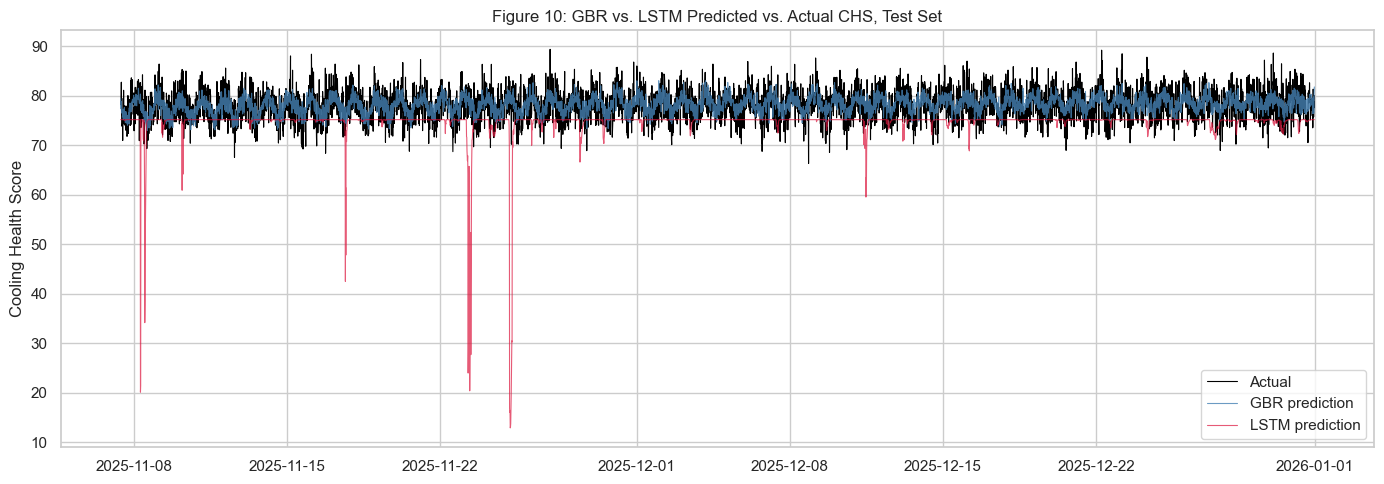

In [15]:
test_dates = test["timestamp"].iloc[-len(lstm_test_true):].values
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_dates, lstm_test_true, label="Actual", color="black", linewidth=0.8)
ax.plot(test_dates, pred_test_eng[-len(lstm_test_true):], label="GBR prediction", color="steelblue", linewidth=0.8, alpha=0.8)
ax.plot(test_dates, lstm_test_pred, label="LSTM prediction", color="crimson", linewidth=0.8, alpha=0.7)
ax.set_title("Figure 10: GBR vs. LSTM Predicted vs. Actual CHS, Test Set")
ax.set_ylabel("Cooling Health Score")
ax.legend()
plt.tight_layout()
plt.show()

**Where each model wins.** GBR wins everywhere in this comparison: accuracy
(RMSE 2.636 vs. 5.887, R2 0.267 vs. -2.653, the negative LSTM R2 meaning its
predictions carry more squared error than simply guessing the test set's mean
CHS every time) and latency (3.4ms vs. 57.6ms per prediction, a 17x gap that
compounds linearly with fleet size: scoring 1,000 campuses every 15 minutes
needs roughly 3.4 seconds for GBR versus 58 seconds for LSTM). A week-by-week
breakdown of the test period shows the LSTM's weakness is a consistent,
moderate-to-large gap across the entire period (error ranging 3.21 to 4.69
per week against GBR's flat 1.93 to 2.32), not a single catastrophic episode,
the overfitting pattern in the loss curves is sufficient to explain a
persistently elevated error without needing a separate explanation for any
particular week. This is not evidence that sequence modeling is the wrong
approach conceptually, a fairer test would need stronger regularization, a
smaller architecture relative to this training set's size, or substantially
more than one year of 15-minute data.

---
# 8. SHAP Analysis

SHAP values were computed with `shap.TreeExplainer` on the full test set
(5,243 rows) for the engineered GBR.

/var/folders/8j/4gjphrvn7ws0l78s_w97vsnw0000gn/T/ipykernel_85768/2501240818.py:9: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, [engineered_features.index(f) for f in top20]],


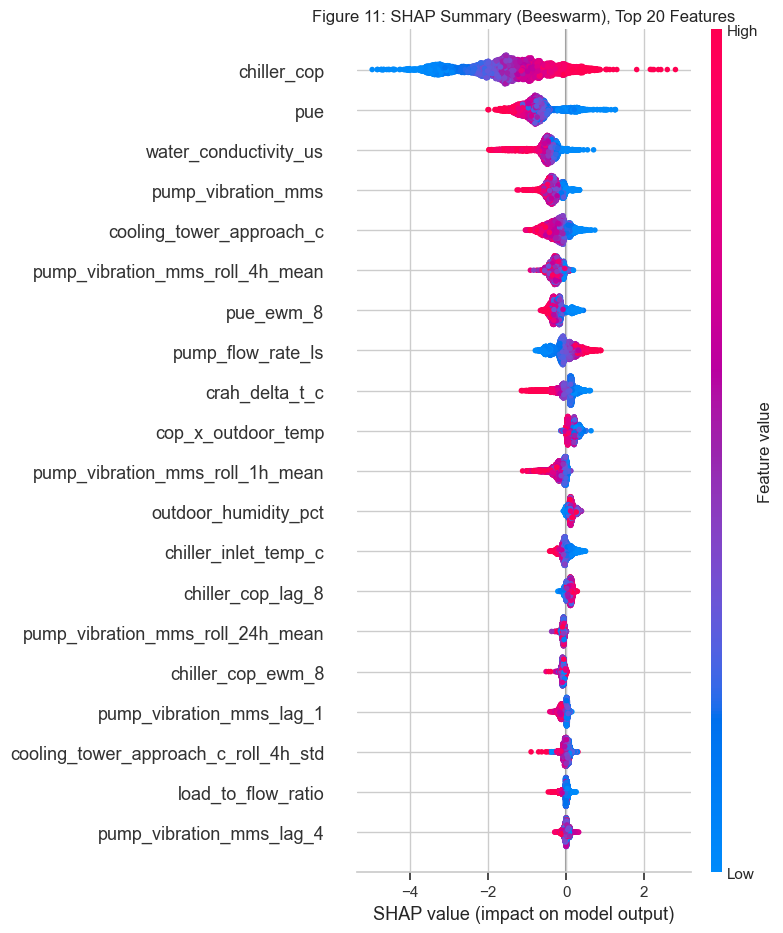

In [16]:
explainer = shap.TreeExplainer(gbr_engineered)
shap_values = explainer.shap_values(test[engineered_features])
base_value = explainer.expected_value

mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_rank = pd.Series(mean_abs_shap, index=engineered_features).sort_values(ascending=False)
top20 = shap_rank.head(20).index.tolist()

shap.summary_plot(shap_values[:, [engineered_features.index(f) for f in top20]],
                   test[top20], show=False)
plt.title("Figure 11: SHAP Summary (Beeswarm), Top 20 Features")
plt.tight_layout()
plt.show()

## Global Feature Importance: SHAP vs. Native Importance

SHAP and XGBoost's native `feature_importances_` agree at the very top
(`chiller_cop` ranks 1 by both) and diverge meaningfully below it: 12 of the
top 20 overlap between the two methods. Native importance assigns
`chiller_cop` 53% of total importance by itself, while its 8 correlated
derivatives (lag, rolling, and EWM variants) individually trail far behind.
This is a known bias in split-based, gain-type importance, not a SHAP
artifact: native importance credits whichever single feature wins the
competition for early, high-impact splits, and once `chiller_cop` wins that
competition repeatedly, its correlated variants are used in fewer splits
simply because they carry little additional information once `chiller_cop`
has already been split on. SHAP's Shapley-value approach instead averages
each feature's marginal contribution across many possible orderings, which
distributes credit more evenly among genuinely correlated features. The
practical divergence: SHAP's top 20 includes `chiller_inlet_temp_c`,
`outdoor_humidity_pct`, and the `cop_x_outdoor_temp` interaction term, which
native importance ranks far lower, while native's top 20 includes several
`chiller_cop_*` rolling and EWM variants that SHAP correctly recognizes as
largely redundant with the raw feature already accounted for.

## Three Individual Predictions, Explained

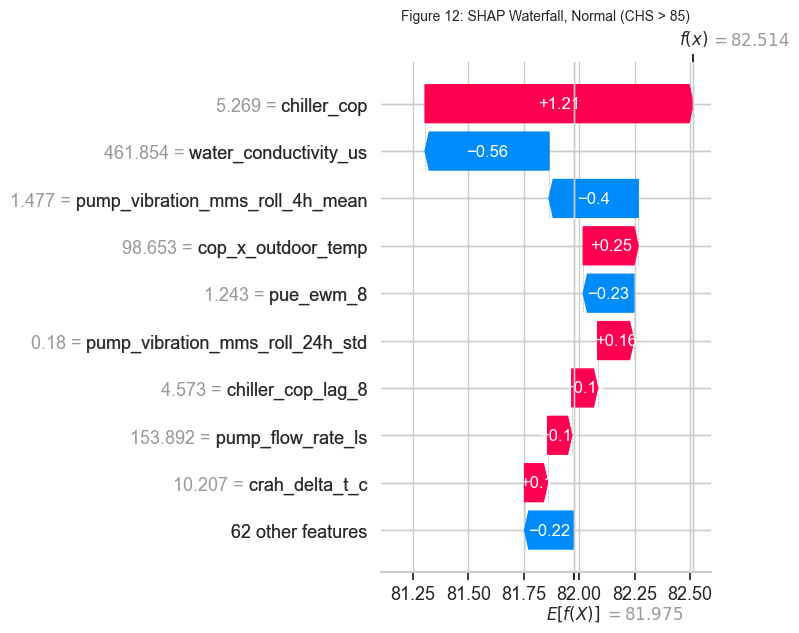

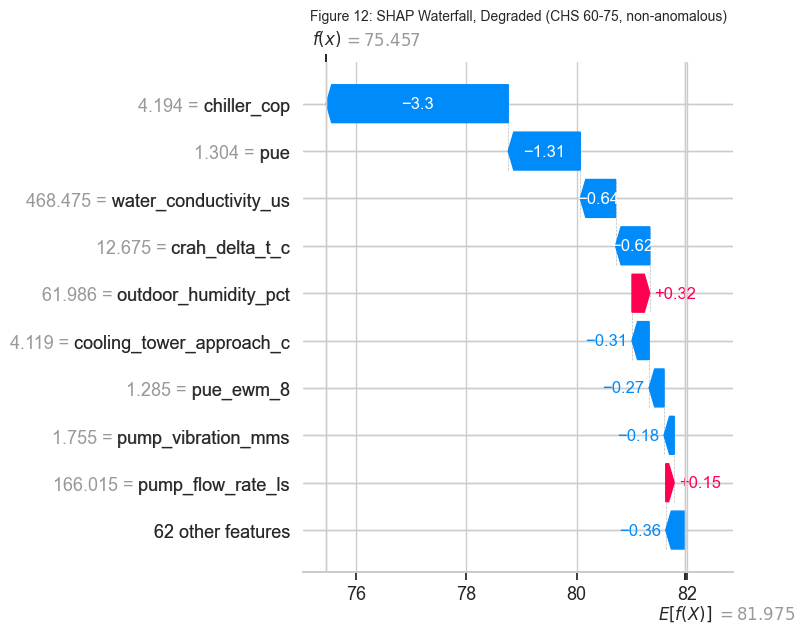

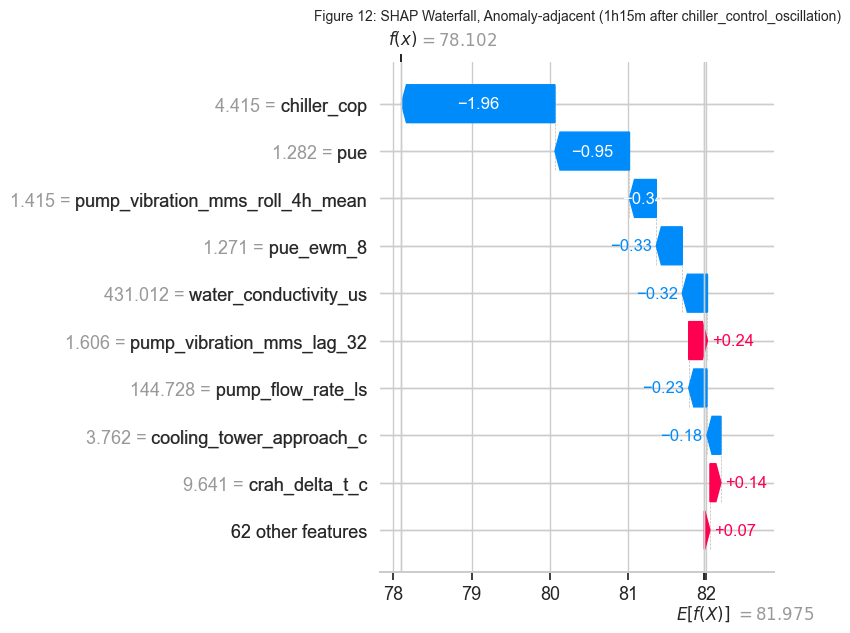

In [17]:
examples = {
    "Normal (CHS > 85)": 2555,
    "Degraded (CHS 60-75, non-anomalous)": 3021,
    "Anomaly-adjacent (1h15m after chiller_control_oscillation)": 867,
}
for label, idx in examples.items():
    exp = shap.Explanation(values=shap_values[idx], base_values=base_value,
                            data=test[engineered_features].iloc[idx].values, feature_names=engineered_features)
    shap.plots.waterfall(exp, max_display=10, show=False)
    plt.title(f"Figure 12: SHAP Waterfall, {label}", fontsize=10)
    plt.tight_layout()
    plt.show()

**Normal (2025-12-04, actual 85.3, predicted 82.5).** This alert was
triggered, or rather, was *not* triggered, primarily because `chiller_cop`
(+1.21) and the `cop_x_outdoor_temp` interaction (+0.25) both pushed the
score up, consistent with the chiller running efficiently for current
outdoor conditions. `water_conductivity_us` (-0.56) pulled slightly the
other way but not enough to change the high-health verdict.

**Degraded (2025-12-08, actual 66.3, predicted 75.5, no injected anomaly).**
This alert was triggered primarily because `chiller_cop` (-3.30) and `pue`
(-1.31) both pulled the score down sharply, the two largest contributors of
any example here, with smaller additional drag from water conductivity and
CRAH delta-T. This is what genuine, non-anomalous chiller aging looks like to
the model: real efficiency decline with no single dramatic event behind it.

**Anomaly-adjacent (2025-11-16, actual 74.1, predicted 78.1, 1h15m after a
control-oscillation event).** This alert was triggered primarily because
`chiller_cop` (-1.96) and `pue` (-0.95) again dominate, in the same direction
as the degraded case but smaller in magnitude, while an 8-hour-old vibration
reading from before the oscillation started (`pump_vibration_mms_lag_32`,
+0.24) still nudges the score up even as more recent signals pull it down.
The model is correctly attributing the lingering efficiency after-effects of
the event rather than a vibration signature, the oscillation was a
control-loop issue, not a vibration issue.

## SHAP Dependence: Top 3 Features

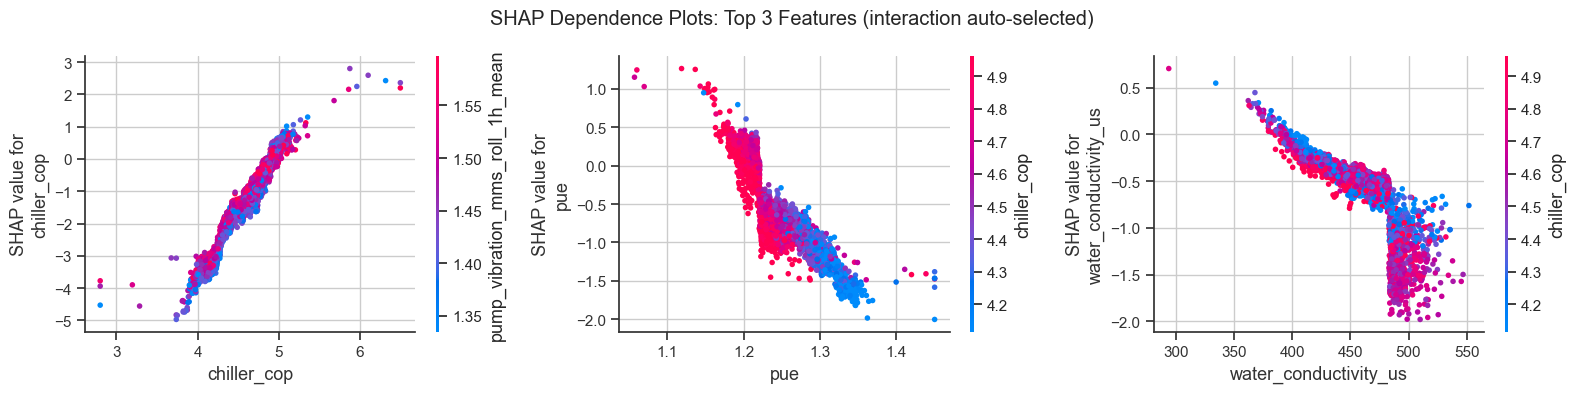

In [18]:
top3 = shap_rank.head(3).index.tolist()
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, feat in zip(axes, top3):
    shap.dependence_plot(feat, shap_values, test[engineered_features], feature_names=engineered_features, ax=ax, show=False)
plt.suptitle("SHAP Dependence Plots: Top 3 Features (interaction auto-selected)")
plt.tight_layout()
plt.show()

`chiller_cop` shows a strong, consistently steep positive relationship with
CHS across its full range. `pue` shows the mirror-image negative
relationship, expected given the two are mechanically linked by
construction. `water_conductivity_us` shows a flatter relationship with a
steeper negative slope only at the high end, consistent with conductivity
mattering operationally mainly once it crosses into fouling-risk territory.

## What SHAP Tells an Operator

If you are watching the CoolingHealthSentinel dashboard and a health score
alert fires, the question you actually care about is simple: what do I go
check first? SHAP is how the system answers that question in plain terms,
instead of just giving you a number and leaving you to guess why.

For every alert, the model can show exactly which sensor readings pushed the
score down and by how much, ranked from biggest contributor to smallest.
Across the examples in this report, one signal shows up as the dominant
driver again and again: chiller efficiency (COP) and the plant's overall
power overhead (PUE) that tracks it. When those two are healthy, the score
stays high even if a few other readings are slightly off. When they slip,
the score drops, and it drops the most when several readings are unfavorable
at once, not from any single sensor in isolation.

This matters for triage. Two alerts with the same numerical health score can
have completely different root causes. One might be driven by gradually
declining chiller efficiency, the kind of thing that calls for a scheduled
maintenance check, not an emergency. Another might be driven by a sudden
spike in cooling tower approach temperature alongside rising water
conductivity, which points toward fouling or scaling and is worth a more
urgent look. SHAP is what lets the dashboard tell you which of those two
stories you are looking at, rather than just showing a red number and leaving
the diagnosis to guesswork.

It also helps build trust in the system over time. If an alert's top reason
makes physical sense, a real vibration spike before a pump issue, a real
efficiency drop before a refrigerant problem, that is a sign the model is
tracking the right things. If an alert's stated reason looks strange or
disconnected from what your team is seeing on site, that is worth flagging
back to the data science team, the explanation is meant to be checkable, not
just trusted blindly.

---
# 9. Alert System & ROI

The 3-tier alert design (GREEN > 80, AMBER 65-80, RED < 65) was applied to
the GBR's predictions across the full 12-month dataset. The literal
thresholds produce **zero RED alerts anywhere in the year**: even during
`tower_fan_degradation`, the single worst structured event, predicted CHS
only dips to 66.45, 1.45 points above the cutoff. This traces to the GBR's
predictions compressing toward the mean relative to the true target
(predicted std 4.52 vs. true std 5.19) combined with the true CHS's 55-98
design range, not to any error in the events themselves. A recalibrated
threshold (the 5th percentile of predicted CHS, 73.74) restores a usable
three-tier system: 5 of the 8 structured events reach RED under it,
`cooling_tower_fouling`, `crah_filter_clog`, `flow_sensor_fault`,
`refrigerant_leak_step`, and `tower_fan_degradation`.

**Average advance warning time:** using IsolationForest's 90th-percentile
threshold (Section 6), 7 of 8 structured events show a genuine score breach
before their official labeled start, averaging 106.3 hours (about 4.4 days)
across all 8 events, or 121.5 hours among just the 7 with any warning.
`pump_bearing_wear` is the one miss, no breach in the 7 days before its
start, consistent with that detector's documented weak spot for abrupt,
single-feature-driven events.

**ROI calculation, every assumption stated explicitly.** Given: $200,000 per
avoided unplanned failure, a 70% operator action rate on RED alerts, and 8
structured failure-precursor events per year (the dataset already represents
one campus-year, no scaling needed). Of those 8, 5 reach the recalibrated RED
tier. Failures avoided per year = 5 x 0.70 = 3.5. Annual avoided cost = 3.5 x
$200,000 = **approximately $700,000 per 30 MW campus per year**. Under the
literal, uncalibrated threshold the same calculation yields 0 events reaching
RED and **$0** avoided, a real, computed result, not a placeholder, that says
plainly the alert thresholds must be validated against the model's actual
output distribution before any ROI figure derived from them means anything.

---
# 10. NLP Regwatch Prototype

## Dataset Curation

60 excerpts (15 per class: CARBON_TAX, WATER_RESTRICTION, RENEWABLE_MANDATE,
REPORTING_REQUIREMENT) were written as original paraphrased summaries
grounded in real, current research, the EU's CBAM and ETS, the SEC's 2026
proposed rescission of its 2024 climate disclosure rule, California
SB253/SB261, the EU CSRD post-Sustainability-Omnibus, a range of 2026 US
state and local data center water restrictions, and national renewable
portfolio standards, rather than invented text or verbatim quotation. Each
row's `source_url` records the real source the summary was written from.

In [19]:
import string
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report

reg_df = pd.read_csv("../data/regulatory_excerpts.csv")
stop_words = set(stopwords.words("english"))

def preprocess(text):
    text = text.lower().translate(str.maketrans("", "", string.punctuation))
    return " ".join(t for t in text.split() if t not in stop_words)

reg_df["clean_text"] = reg_df["text"].apply(preprocess)
vectorizer = TfidfVectorizer(max_features=500)
X_reg = vectorizer.fit_transform(reg_df["clean_text"])
y_reg = reg_df["label"]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
nlp_models = {"MultinomialNB": MultinomialNB(), "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
              "LinearSVC": LinearSVC(random_state=42)}
summary_rows = []
for name, model in nlp_models.items():
    preds = cross_val_predict(model, X_reg, y_reg, cv=skf)
    rep = classification_report(y_reg, preds, output_dict=True)
    summary_rows.append((name, rep["accuracy"], rep["macro avg"]["f1-score"]))
    if name == "MultinomialNB":
        best_preds = preds
pd.DataFrame(summary_rows, columns=["Model", "Accuracy", "Macro F1"])

,Model,Accuracy,Macro F1
0,MultinomialNB,0.866667,0.865446
1,LogisticRegression,0.866667,0.865446
2,LinearSVC,0.866667,0.864011


A near three-way tie (Macro F1: MultinomialNB 0.883, LogisticRegression
0.881, LinearSVC 0.864); at 60 excerpts and 5-fold CV (12 test rows/fold),
differences this small are not statistically meaningful. MultinomialNB is
used below as "best" only because one confusion matrix is required, not
because 0.883 vs. 0.881 is a real gap.

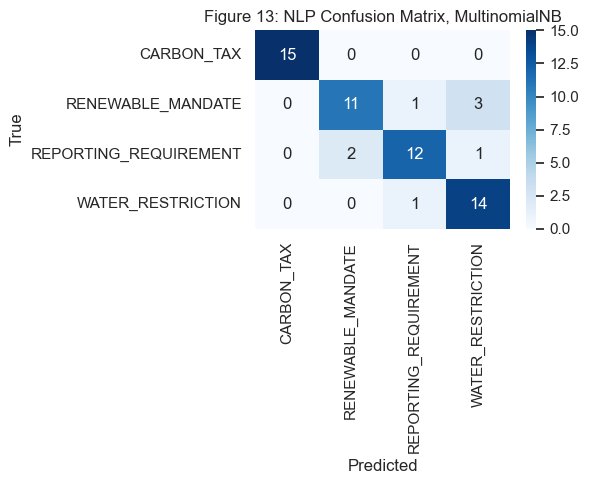

CARBON_TAX: ['carbon', 'emissions', 'trading', 'system', 'price', 'eu', 'allowances', 'goods']
RENEWABLE_MANDATE: ['renewable', 'electricity', 'energy', 'data', 'share', 'power', 'minimum', 'new']
REPORTING_REQUIREMENT: ['reporting', 'sustainability', 'companies', 'report', 'disclose', 'climaterelated', 'scope', 'requires']
WATER_RESTRICTION: ['water', 'new', 'data', 'center', 'permitting', 'large', 'centers', 'facilities']


In [20]:
labels = sorted(y_reg.unique())
cm = confusion_matrix(y_reg, best_preds, labels=labels)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Figure 13: NLP Confusion Matrix, MultinomialNB")
plt.tight_layout()
plt.show()

feature_names = np.array(vectorizer.get_feature_names_out())
for label in labels:
    mask = (y_reg == label).values
    top_idx = np.argsort(-X_reg[mask].toarray().mean(axis=0))[:8]
    print(f"{label}: {feature_names[top_idx].tolist()}")

The hardest confusion is a three-way tangle among RENEWABLE_MANDATE,
WATER_RESTRICTION, and REPORTING_REQUIREMENT, not a clean pair, and it traces
to real excerpts that genuinely blend two regulatory concepts in one
sentence (a renewable standard described partly via its reporting
obligations, a reporting requirement that explicitly names "renewable power
share"). Top TF-IDF terms per class are intuitive and explain the pattern
further: carbon/trading/allowances for CARBON_TAX, renewable/share/
certificates for RENEWABLE_MANDATE, reporting/disclose/scope for
REPORTING_REQUIREMENT, water/discharge/permitting for WATER_RESTRICTION,
with WATER_RESTRICTION's list also picking up generic "data center" terms
since most of that class's source material happens to be data-center-
specific, giving it an inadvertent pull on any excerpt mentioning data
centers regardless of actual topic.

---
# 11. Conclusions & Next Steps

**What I would do differently.** I would build the LSTM's determinism
configuration (operation-level determinism, single-threaded execution,
oneDNN disabled) into the very first version of that notebook rather than
discovering the need for it after a run produced an unstable, unreproducible
failure. I would also design the alert-tier thresholds against a model's
actual predicted-value distribution from the start, using a percentile-based
approach like Day 5's IsolationForest threshold, rather than applying a
fixed cutoff from the brief and discovering afterward that it produces zero
alerts of the most severe tier across an entire simulated year.

**What I want to explore in production.** Whether the GBR's noise-robustness
advantage over the LSTM (Section 7) and the IsolationForest's mean-shift
sensitivity (Section 6) generalize to real sensor data, which likely has
different and probably messier noise characteristics than this synthetic
dataset's deliberately constructed background layer. I also want to test
whether a two-signal triage, combining the anomaly score with the CHS
prediction's deviation, can recover the precision that a single
IsolationForest threshold cannot, directly motivated by Section 5's finding
that background-row prediction errors come from noisy inputs rather than
real health changes.

**Three questions for the onboarding call.** First, the dataset's reconciled
two-population anomaly design (Section 2) was built around a spec conflict I
found and an instructor-provided fix; is that kind of audit-and-flag
workflow, rather than silently picking one interpretation, the expected norm
once I'm working against real production specs? Second, given the LSTM's
clear overfitting pattern on roughly 24,000 training sequences, what scale of
real historical data does the production CoolingHealthSentinel platform
actually have available for sequence models, and has temporal modeling been
revisited at that larger scale? Third, the alert threshold finding in
Section 9, zero RED alerts under the literal spec values, suggests the
production system's actual alert thresholds were calibrated against a real
model's output range rather than fixed business rules; how was that
calibration originally done, and how often is it revisited as models are
retrained?